In [ ]:
from pathlib import Path

import causalts.plotting as tp
import numpy as np

from charl_tre.settings import Settings

P_VALUE_THRESHOLD = 0.3

settings = Settings()
latents_dir = Path("../") / settings.study_path / "latents"
causal_dir = Path("../") / settings.study_path / "causal"

adjacency_matrix = np.load(causal_dir / "adjacency_matrix.npy")

alphas = np.load(latents_dir / "alphas.npz")["train"]
_, _, n_mixtures, n_components = alphas.shape

In [34]:
graph = adjacency_matrix[:, :, :, :]["mark"].copy()
val_matrix = adjacency_matrix[:, :, :, :]["value"].copy()

# Filter low p_values
filtered = np.abs(val_matrix) < P_VALUE_THRESHOLD
graph[filtered] = 0
val_matrix[filtered] = 0

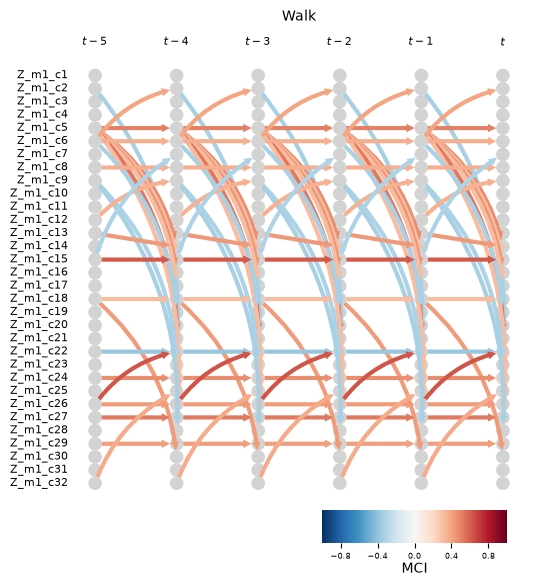

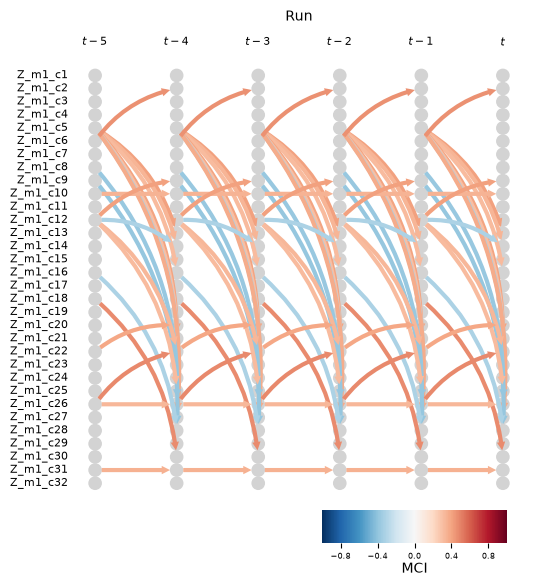

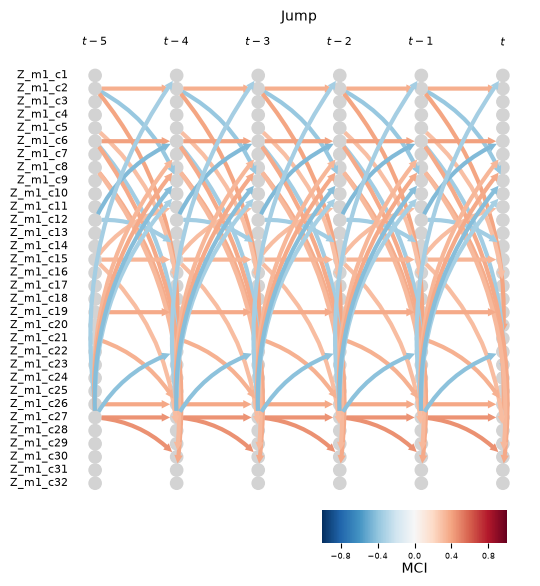

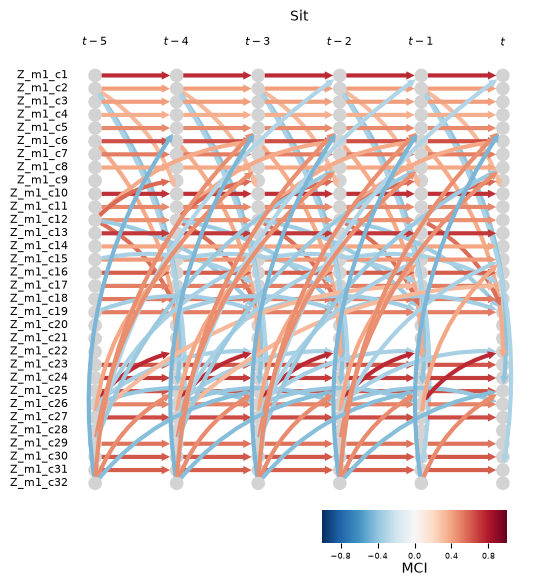

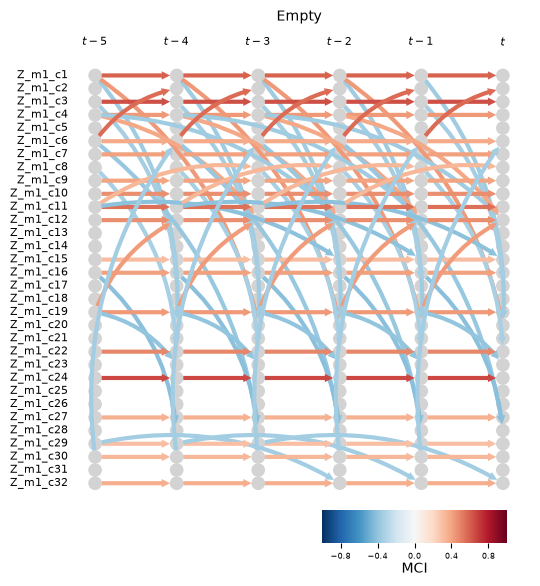

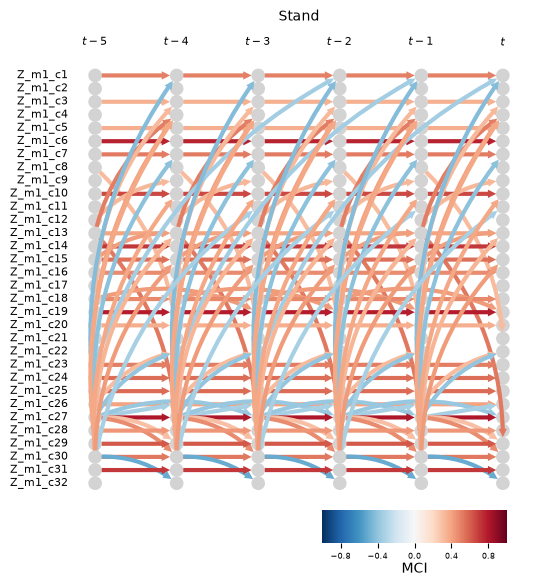

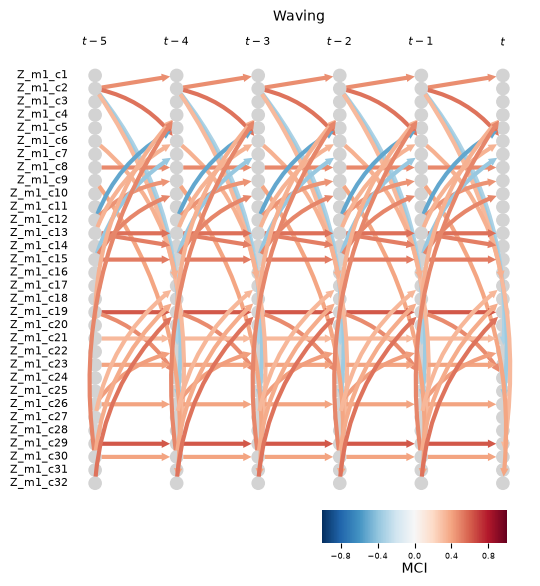

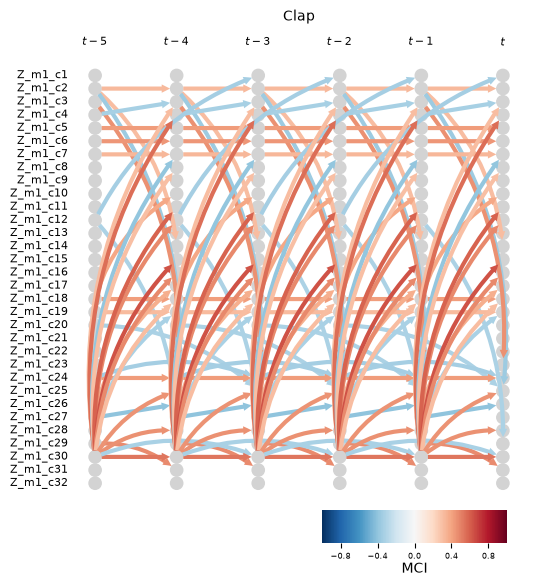

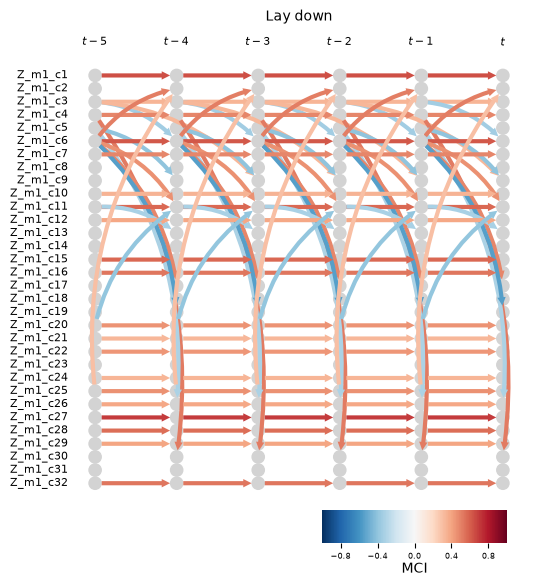

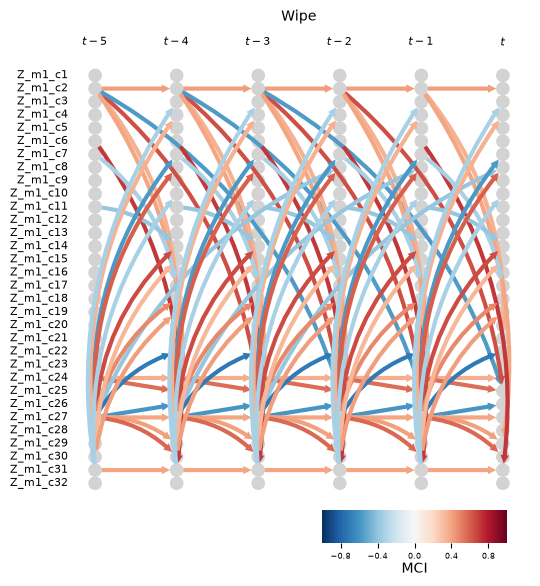

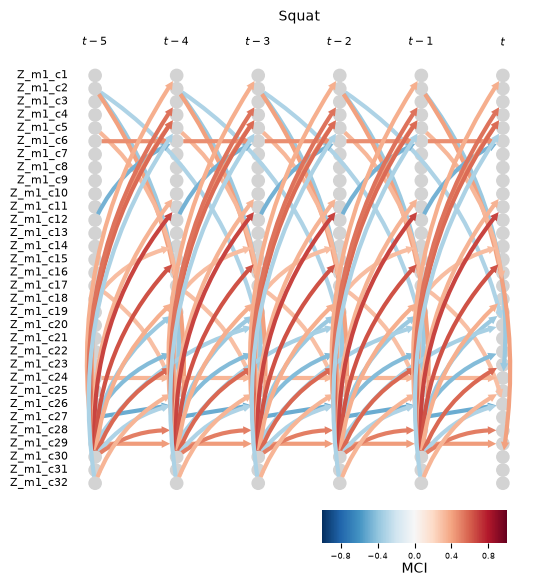

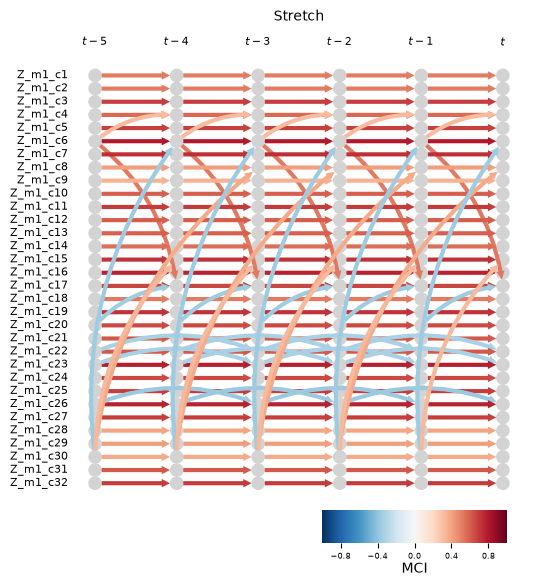

In [36]:
for activity in range(settings.n_activities):
    tp.plot_time_series_graph(  # pyright: ignore[reportPrivateImportUsage]
        graph[activity],
        val_matrix=val_matrix[activity],
        var_names=[
            f"Z_m{mixture + 1}_c{component + 1}"
            for mixture in range(n_mixtures)
            for component in range(n_components)
        ],
        order=list(range(n_mixtures * n_components)),
        title=settings.activities[activity],
        arrow_linewidth=3,
        node_size=0.03,
        figsize=(12, 6),
        node_label_size=8,
    )